# ESM GO Split Tuning with GO Frequency Filtering (<20)

This notebook is based on the original `ESM_GO_split_tuning.ipynb`.

The only major change is:

> Before splitting GO terms into BPO / CCO / MFO, we remove GO terms with training frequency < 20.

Everything else is kept from the original workflow:
- Load ESM embeddings
- Reuse k-mer train/validation split
- Standardize ESM embeddings
- Split GO labels into BPO / CCO / MFO
- Build namespace-specific datasets
- Build namespace-specific `pos_weight`
- Train baseline models
- Train tuned models
- Compute threshold-based micro-F1 / macro-F1
- Load IA weights
- Compute IA-weighted F1-max
- Compare baseline vs tuned
- Plot comparison figures
- Save outputs

## Step 0. Imports and Global Settings

### Why this step?
We import libraries for data loading, sparse matrix handling, PyTorch training, threshold-based evaluation, IA-weighted F1-max, and plotting.

In [31]:
import os
import copy
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import load_npz

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score

DATA_DIR = "data_processed_esm"
KMER_DATA_DIR = "../kmer/data_processed_kmer_70"

TERMS_PATH = os.path.join("..", "cafa-5-protein-function-prediction", "Train", "train_terms.tsv")
IA_PATH = os.path.join("..", "cafa-5-protein-function-prediction", "IA.txt")

# K-mer test metrics produced from the 70/15/15 split notebook
KMER_TEST_METRICS_PATH = os.path.join("../kmer/kmer_GO_split_freq20_outputs", "kmer_test_metrics.csv")

FREQ_THRESHOLD = 20
OUTPUT_DIR = "esm_GO_split_freq20_full_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("DATA_DIR:", DATA_DIR)
print("KMER_DATA_DIR:", KMER_DATA_DIR)
print("KMER_TEST_METRICS_PATH:", KMER_TEST_METRICS_PATH)
print("FREQ_THRESHOLD:", FREQ_THRESHOLD)
print("OUTPUT_DIR:", OUTPUT_DIR)


Device: cpu
DATA_DIR: data_processed_esm
KMER_DATA_DIR: ../kmer/data_processed_kmer_70
KMER_TEST_METRICS_PATH: ../kmer/kmer_GO_split_freq20_outputs/kmer_test_metrics.csv
FREQ_THRESHOLD: 20
OUTPUT_DIR: esm_GO_split_freq20_full_outputs


## Step 1. Load ESM Embeddings and GO Labels

### Why this step?
The ESM preprocessing pipeline has already generated one embedding vector per protein.

We load:
- ESM embeddings
- sparse or dense GO label matrix
- protein IDs if available
- GO term encoder / metadata

This notebook supports both common file names:
- `X_esm.npy`
- `X.npy`

In [2]:
# Load ESM embeddings
x_esm_path = os.path.join(DATA_DIR, "X_esm.npy")
x_path = os.path.join(DATA_DIR, "X.npy")

if os.path.exists(x_esm_path):
    X_esm = np.load(x_esm_path)
    print("Loaded ESM embeddings from:", x_esm_path)
elif os.path.exists(x_path):
    X_esm = np.load(x_path)
    print("Loaded ESM embeddings from:", x_path)
else:
    raise FileNotFoundError("Cannot find X_esm.npy or X.npy in data_processed_esm")

# Load GO label matrix
y_sparse_path = os.path.join(DATA_DIR, "Y_sparse.npz")
y_dense_path = os.path.join(DATA_DIR, "Y.npy")

if os.path.exists(y_sparse_path):
    Y = load_npz(y_sparse_path)
    print("Loaded sparse Y:", Y.shape, type(Y))
elif os.path.exists(y_dense_path):
    Y = np.load(y_dense_path)
    print("Loaded dense Y:", Y.shape, type(Y))
else:
    raise FileNotFoundError("Cannot find Y_sparse.npz or Y.npy in data_processed_esm")

# Load protein IDs if available
protein_ids_path = os.path.join(DATA_DIR, "protein_ids.pkl")
if os.path.exists(protein_ids_path):
    with open(protein_ids_path, "rb") as f:
        protein_ids = pickle.load(f)
    print("protein_ids length:", len(protein_ids))
else:
    protein_ids = None
    print("protein_ids.pkl not found; continuing without protein IDs.")

print("X_esm shape:", X_esm.shape, X_esm.dtype)
print("Y shape:", Y.shape)
assert X_esm.shape[0] == Y.shape[0], "X_esm and Y are not aligned!"

Loaded ESM embeddings from: data_processed_esm/X_esm.npy
Loaded sparse Y: (140569, 31454) <class 'scipy.sparse._csr.csr_matrix'>
protein_ids.pkl not found; continuing without protein IDs.
X_esm shape: (140569, 640) float32
Y shape: (140569, 31454)


## Step 2. Load GO Term Order

### Why this step?
The columns of `Y` correspond to specific GO terms.  
To filter labels and split BPO / CCO / MFO correctly, we need the exact GO term order used during multi-label encoding.

Usually this is stored in `mlb.pkl`.

In [3]:
mlb_path = os.path.join(DATA_DIR, "mlb.pkl")
meta_path = os.path.join(DATA_DIR, "meta.pkl")

if os.path.exists(mlb_path):
    with open(mlb_path, "rb") as f:
        mlb = pickle.load(f)
    go_terms = list(mlb.classes_)
    print("Loaded GO terms from mlb.pkl")
elif os.path.exists(meta_path):
    with open(meta_path, "rb") as f:
        meta = pickle.load(f)

    if isinstance(meta, dict) and "go_terms" in meta:
        go_terms = meta["go_terms"].tolist() if hasattr(meta["go_terms"], "tolist") else list(meta["go_terms"])
        print("Loaded GO terms from meta['go_terms']")
    elif isinstance(meta, dict) and "mlb" in meta:
        go_terms = list(meta["mlb"].classes_)
        print("Loaded GO terms from meta['mlb'].classes_")
    elif hasattr(meta, "classes_"):
        go_terms = list(meta.classes_)
        print("Loaded GO terms from meta.classes_")
    else:
        raise KeyError("Could not find GO term order in meta.pkl")
else:
    raise FileNotFoundError("Could not find mlb.pkl or meta.pkl in data_processed_esm")

print("Number of GO terms:", len(go_terms))
print("Y columns:", Y.shape[1])
assert len(go_terms) == Y.shape[1], "GO term order does not match Y columns."

Loaded GO terms from mlb.pkl
Number of GO terms: 31454
Y columns: 31454


## Step 3. Reuse the Same Train/Validation/Test Split as K-mer

### Why this step?
To fairly compare ESM and k-mer models, both should use the same proteins in the train, validation, and test sets.

We reuse:
- `train_idx.npy`
- `val_idx.npy`
- `test_idx.npy`

from the k-mer 70/15/15 preprocessing output.


In [6]:
train_idx = np.load(os.path.join(KMER_DATA_DIR, "train_idx.npy"))
val_idx = np.load(os.path.join(KMER_DATA_DIR, "val_idx.npy"))
test_idx = np.load(os.path.join(KMER_DATA_DIR, "test_idx.npy"))

X_train = X_esm[train_idx]
X_val = X_esm[val_idx]
X_test = X_esm[test_idx]

if hasattr(Y, "tocsr"):
    Y_train = Y[train_idx]
    Y_val = Y[val_idx]
    Y_test = Y[test_idx]
else:
    Y_train = Y[train_idx]
    Y_val = Y[val_idx]
    Y_test = Y[test_idx]

print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)
print("Y_train:", Y_train.shape)
print("Y_val:  ", Y_val.shape)
print("Y_test: ", Y_test.shape)

assert X_train.shape[0] == Y_train.shape[0]
assert X_val.shape[0] == Y_val.shape[0]
assert X_test.shape[0] == Y_test.shape[0]


X_train: (98397, 640)
X_val:   (21086, 640)
X_test:  (21086, 640)
Y_train: (98397, 31454)
Y_val:   (21086, 31454)
Y_test:  (21086, 31454)


## Step 4. Standardize ESM Embeddings

### Why this step?
ESM embeddings can have different numerical scales across dimensions.  
Standardization helps the MLP train more stably.

Important:
- Fit scaler on training set only
- Apply the same scaler to validation set
- Save scaler for reproducibility

In [7]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val = scaler.transform(X_val).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

scaler_path = os.path.join(OUTPUT_DIR, "esm_freq20_scaler.pkl")
with open(scaler_path, "wb") as f:
    pickle.dump(scaler, f)

print("Standardized X_train:", X_train.shape, X_train.dtype)
print("Standardized X_val:  ", X_val.shape, X_val.dtype)
print("Standardized X_test: ", X_test.shape, X_test.dtype)
print("Saved scaler to:", scaler_path)


Standardized X_train: (98397, 640) float32
Standardized X_val:   (21086, 640) float32
Standardized X_test:  (21086, 640) float32
Saved scaler to: esm_GO_split_freq20_full_outputs/esm_freq20_scaler.pkl


## Step 5. Filter GO Terms with Training Frequency > 20

### Why this step?
GO labels are extremely sparse and long-tailed.  
Labels with fewer than 20 positive training examples are unlikely to be learned reliably.

### Important design choice
We compute frequency using `Y_train` only to avoid validation leakage.

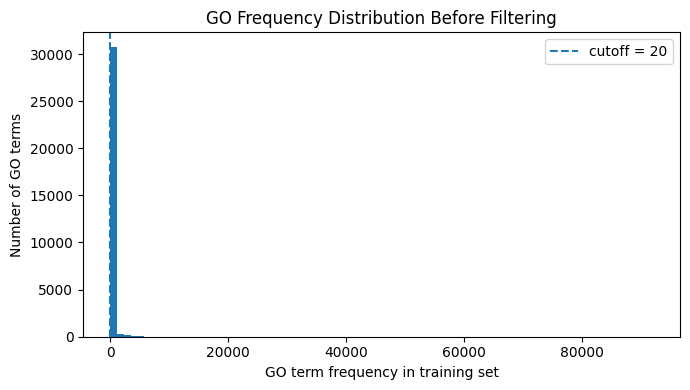

Original GO terms: 31454
Kept GO terms: 10617
Removed GO terms: 20837
Removed percentage: 66.24594646149933
Y_train_filtered: (98397, 10617)
Y_val_filtered:   (21086, 10617)
Y_test_filtered:  (21086, 10617)
Filtered GO terms: 10617


In [8]:
label_counts = np.asarray(Y.sum(axis=0)).ravel().astype(np.float32)

plt.figure(figsize=(7, 4))
plt.hist(label_counts, bins=80)
plt.axvline(FREQ_THRESHOLD, linestyle="--", label=f"cutoff = {FREQ_THRESHOLD}")
plt.xlabel("GO term frequency in training set")
plt.ylabel("Number of GO terms")
plt.title("GO Frequency Distribution Before Filtering")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "go_frequency_distribution_before_filtering.png"), dpi=200, bbox_inches="tight")
plt.show()

keep_idx = np.where(label_counts >= FREQ_THRESHOLD)[0]
removed_idx = np.where(label_counts < FREQ_THRESHOLD)[0]

print("Original GO terms:", Y_train.shape[1])
print("Kept GO terms:", len(keep_idx))
print("Removed GO terms:", len(removed_idx))
print("Removed percentage:", 100 * len(removed_idx) / Y_train.shape[1])

Y_train_filtered = Y_train[:, keep_idx]
Y_val_filtered = Y_val[:, keep_idx]
Y_test_filtered = Y_test[:, keep_idx]

go_terms_filtered = [go_terms[i] for i in keep_idx]

print("Y_train_filtered:", Y_train_filtered.shape)
print("Y_val_filtered:  ", Y_val_filtered.shape)
print("Y_test_filtered: ", Y_test_filtered.shape)
print("Filtered GO terms:", len(go_terms_filtered))


## Step 6. Save Filtering Metadata

### Why this step?
Saving which GO terms were kept makes the experiment reproducible and allows later comparison with the full-label experiment.

In [9]:
filter_metadata = {
    "freq_threshold": int(FREQ_THRESHOLD),
    "original_num_go_terms": int(Y_train.shape[1]),
    "kept_num_go_terms": int(len(keep_idx)),
    "removed_num_go_terms": int(len(removed_idx)),
    "keep_idx": keep_idx.tolist(),
    "removed_idx": removed_idx.tolist(),
    "go_terms_filtered": go_terms_filtered,
}

with open(os.path.join(OUTPUT_DIR, "filter_metadata.json"), "w") as f:
    json.dump(filter_metadata, f, indent=2)

print("Saved filter metadata to:", os.path.join(OUTPUT_DIR, "filter_metadata.json"))

Saved filter metadata to: esm_GO_split_freq20_full_outputs/filter_metadata.json


## Step 7. Load GO Namespace Mapping

### Why this step?
After filtering, we need to rebuild BPO / CCO / MFO indices based on the filtered GO term order.

In [10]:
terms_df = pd.read_csv(TERMS_PATH, sep="\t")

go_to_aspect = (
    terms_df[["term", "aspect"]]
    .drop_duplicates()
    .set_index("term")["aspect"]
    .to_dict()
)

bpo_idx = [i for i, go in enumerate(go_terms_filtered) if go_to_aspect.get(go) == "BPO"]
cco_idx = [i for i, go in enumerate(go_terms_filtered) if go_to_aspect.get(go) == "CCO"]
mfo_idx = [i for i, go in enumerate(go_terms_filtered) if go_to_aspect.get(go) == "MFO"]

print("Filtered total GO terms:", len(go_terms_filtered))
print("BPO labels:", len(bpo_idx))
print("CCO labels:", len(cco_idx))
print("MFO labels:", len(mfo_idx))
print("Check total:", len(bpo_idx) + len(cco_idx) + len(mfo_idx))

namespace_go_terms = {
    "BPO": [go_terms_filtered[i] for i in bpo_idx],
    "CCO": [go_terms_filtered[i] for i in cco_idx],
    "MFO": [go_terms_filtered[i] for i in mfo_idx],
}

Filtered total GO terms: 10617
BPO labels: 7983
CCO labels: 1065
MFO labels: 1569
Check total: 10617


## Step 8. Split Filtered Target Matrix into BPO / CCO / MFO

### Why this step?
The ESM feature matrix stays the same.  
Only the target matrix is split into namespace-specific label spaces.

In [11]:
Y_train_BPO = Y_train_filtered[:, bpo_idx]
Y_val_BPO   = Y_val_filtered[:, bpo_idx]
Y_test_BPO  = Y_test_filtered[:, bpo_idx]

Y_train_CCO = Y_train_filtered[:, cco_idx]
Y_val_CCO   = Y_val_filtered[:, cco_idx]
Y_test_CCO  = Y_test_filtered[:, cco_idx]

Y_train_MFO = Y_train_filtered[:, mfo_idx]
Y_val_MFO   = Y_val_filtered[:, mfo_idx]
Y_test_MFO  = Y_test_filtered[:, mfo_idx]

print("Y_train_BPO:", Y_train_BPO.shape, "Y_val_BPO:", Y_val_BPO.shape, "Y_test_BPO:", Y_test_BPO.shape)
print("Y_train_CCO:", Y_train_CCO.shape, "Y_val_CCO:", Y_val_CCO.shape, "Y_test_CCO:", Y_test_CCO.shape)
print("Y_train_MFO:", Y_train_MFO.shape, "Y_val_MFO:", Y_val_MFO.shape, "Y_test_MFO:", Y_test_MFO.shape)


Y_train_BPO: (98397, 7983) Y_val_BPO: (21086, 7983) Y_test_BPO: (21086, 7983)
Y_train_CCO: (98397, 1065) Y_val_CCO: (21086, 1065) Y_test_CCO: (21086, 1065)
Y_train_MFO: (98397, 1569) Y_val_MFO: (21086, 1569) Y_test_MFO: (21086, 1569)


## Step 9. Build Dataset and MLP Model

### Why this step?
Each namespace uses the same ESM embeddings but a different target matrix.

In [12]:
class ProteinESMDataset(Dataset):
    def __init__(self, X, Y):
        self.X = X.astype(np.float32)
        self.Y = Y
        self.is_sparse = hasattr(Y, "tocsr")

        if self.is_sparse:
            self.Y = Y.tocsr()
            self.n_labels = self.Y.shape[1]

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = torch.from_numpy(self.X[idx])

        if self.is_sparse:
            start = self.Y.indptr[idx]
            end = self.Y.indptr[idx + 1]
            pos_idx = self.Y.indices[start:end]

            y = torch.zeros(self.n_labels, dtype=torch.float32)
            y[pos_idx] = 1.0
        else:
            y = torch.tensor(self.Y[idx], dtype=torch.float32)

        return x, y


class ESMMLP(nn.Module):
    def __init__(self, input_dim, output_dim, hidden1=256, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, output_dim)
        )

    def forward(self, x):
        return self.net(x)

## Step 10. Build Namespace-Specific Datasets and Loss Functions

### Why this step?
Each namespace has a different label distribution, so each one should have its own `pos_weight` and `BCEWithLogitsLoss`.

In [13]:
train_dataset_BPO = ProteinESMDataset(X_train, Y_train_BPO)
val_dataset_BPO   = ProteinESMDataset(X_val, Y_val_BPO)

train_dataset_CCO = ProteinESMDataset(X_train, Y_train_CCO)
val_dataset_CCO   = ProteinESMDataset(X_val, Y_val_CCO)

train_dataset_MFO = ProteinESMDataset(X_train, Y_train_MFO)
val_dataset_MFO   = ProteinESMDataset(X_val, Y_val_MFO)

print("BPO dataset sizes:", len(train_dataset_BPO), len(val_dataset_BPO))
print("CCO dataset sizes:", len(train_dataset_CCO), len(val_dataset_CCO))
print("MFO dataset sizes:", len(train_dataset_MFO), len(val_dataset_MFO))


def build_namespace_criterion(Y_train_namespace, device):
    label_counts_ns = np.asarray(Y_train_namespace.sum(axis=0)).ravel().astype(np.float32)
    n_train = Y_train_namespace.shape[0]

    pos_weight = (n_train - label_counts_ns) / (label_counts_ns + 1e-6)
    pos_weight = np.clip(pos_weight, 1.0, 100.0)

    pos_weight_tensor = torch.tensor(pos_weight, dtype=torch.float32, device=device)
    return nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)


criterion_BPO = build_namespace_criterion(Y_train_BPO, device)
criterion_CCO = build_namespace_criterion(Y_train_CCO, device)
criterion_MFO = build_namespace_criterion(Y_train_MFO, device)

print("Built namespace-specific criteria.")

BPO dataset sizes: 98397 21086
CCO dataset sizes: 98397 21086
MFO dataset sizes: 98397 21086
Built namespace-specific criteria.


## Step 11. Training and Evaluation Helper Functions

### Why this step?
These helper functions keep training reusable for baseline and tuned models across BPO / CCO / MFO.

In [14]:
def build_dataloaders(train_dataset, val_dataset, batch_size):
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=4,
        pin_memory=torch.cuda.is_available()
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=4,
        pin_memory=torch.cuda.is_available()
    )

    return train_loader, val_loader


def build_model(config, input_dim, output_dim, device):
    return ESMMLP(
        input_dim=input_dim,
        output_dim=output_dim,
        hidden1=config["hidden1"],
        #hidden2=config["hidden2"],
        dropout=config["dropout"]
    ).to(device)


def build_optimizer(model, config):
    return optim.Adam(
        model.parameters(),
        lr=config["learning_rate"],
        weight_decay=config["weight_decay"]
    )


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0

    for X_batch, Y_batch in loader:
        X_batch = X_batch.to(device, non_blocking=True)
        Y_batch = Y_batch.to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, Y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def evaluate_loss(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0

    for X_batch, Y_batch in loader:
        X_batch = X_batch.to(device, non_blocking=True)
        Y_batch = Y_batch.to(device, non_blocking=True)

        logits = model(X_batch)
        loss = criterion(logits, Y_batch)

        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()
    all_probs = []
    all_targets = []

    for X_batch, Y_batch in loader:
        X_batch = X_batch.to(device, non_blocking=True)

        logits = model(X_batch)
        probs = torch.sigmoid(logits).cpu().numpy()

        all_probs.append(probs)
        all_targets.append(Y_batch.numpy())

    all_probs = np.vstack(all_probs)
    all_targets = np.vstack(all_targets)

    return all_probs, all_targets

In [15]:
def threshold_sweep(y_true, y_prob, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.05, 0.95, 0.1)

    records = []

    for t in thresholds:
        y_pred = (y_prob >= t).astype(np.int8)

        micro = f1_score(y_true, y_pred, average="micro", zero_division=0)
        macro = f1_score(y_true, y_pred, average="macro", zero_division=0)

        records.append({
            "threshold": float(t),
            "micro_f1": float(micro),
            "macro_f1": float(macro),
        })

    best_micro_row = max(records, key=lambda x: x["micro_f1"])
    best_macro_row = max(records, key=lambda x: x["macro_f1"])

    return records, best_micro_row, best_macro_row


def train_with_early_stopping(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    num_epochs=5,
    patience=3,
    save_path=None
):
    best_val_loss = float("inf")
    best_state_dict = None
    epochs_no_improve = 0

    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss = evaluate_loss(model, val_loader, criterion, device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1:02d}/{num_epochs} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state_dict = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0

            if save_path is not None:
                torch.save(best_state_dict, save_path)
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    return model, train_losses, val_losses, best_val_loss

In [16]:
def run_experiment(
    config,
    train_dataset,
    val_dataset,
    input_dim,
    output_dim,
    criterion,
    device,
    run_threshold_sweep=True
):
    train_loader, val_loader = build_dataloaders(
        train_dataset=train_dataset,
        val_dataset=val_dataset,
        batch_size=config["batch_size"]
    )

    model = build_model(config, input_dim, output_dim, device)
    optimizer = build_optimizer(model, config)

    save_path = os.path.join(OUTPUT_DIR, f"{config['save_prefix']}.pt")

    model, train_losses, val_losses, best_val_loss = train_with_early_stopping(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        num_epochs=config["num_epochs"],
        patience=config["patience"],
        save_path=save_path
    )

    result = {
        "config": config.copy(),
        "model": model,
        "model_path": save_path,
        "best_val_loss": best_val_loss,
        "train_losses": train_losses,
        "val_losses": val_losses,
    }

    if run_threshold_sweep:
        val_probs, val_targets = get_predictions(model, val_loader, device)
        records, best_micro_row, best_macro_row = threshold_sweep(val_targets, val_probs)

        result["threshold_records"] = records
        result["best_micro_row"] = best_micro_row
        result["best_macro_row"] = best_macro_row

    return result

## Step 12. Define Baseline and Tuned Configurations

### Why this step?
We compare:
- baseline MLP configuration
- tuned MLP configuration

These match the original ESM GO split tuning workflow, but now use the filtered GO label space.

In [17]:
BASELINE_NAMESPACE_CONFIG = {
    "hidden1": 512,
    #"hidden2": 256,
    "dropout": 0.3,
    "learning_rate": 1e-3,
    "weight_decay": 1e-5,
    "batch_size": 64,
    "num_epochs": 5,
    "patience": 3,
    "save_prefix": "esm_freq20_baseline_namespace"
}

TUNED_NAMESPACE_CONFIG = {
    "hidden1": 256,
    #"hidden2": 512,
    "dropout": 0.3,
    "learning_rate": 1e-3,
    "weight_decay": 0.0,
    "batch_size": 64,
    "num_epochs": 5,
    "patience": 3,
    "save_prefix": "esm_freq20_tuned_namespace"
}

input_dim = X_train.shape[1]

print("BASELINE_NAMESPACE_CONFIG:")
print(BASELINE_NAMESPACE_CONFIG)
print()
print("TUNED_NAMESPACE_CONFIG:")
print(TUNED_NAMESPACE_CONFIG)
print()
print("input_dim:", input_dim)

BASELINE_NAMESPACE_CONFIG:
{'hidden1': 512, 'dropout': 0.3, 'learning_rate': 0.001, 'weight_decay': 1e-05, 'batch_size': 64, 'num_epochs': 5, 'patience': 3, 'save_prefix': 'esm_freq20_baseline_namespace'}

TUNED_NAMESPACE_CONFIG:
{'hidden1': 256, 'dropout': 0.3, 'learning_rate': 0.001, 'weight_decay': 0.0, 'batch_size': 64, 'num_epochs': 5, 'patience': 3, 'save_prefix': 'esm_freq20_tuned_namespace'}

input_dim: 640


## Step 13. Train Baseline Models for BPO / CCO / MFO

In [18]:
# Baseline BPO
config_BPO_base = BASELINE_NAMESPACE_CONFIG.copy()
config_BPO_base["save_prefix"] = "esm_freq20_BPO_baseline"

result_BPO_base = run_experiment(
    config=config_BPO_base,
    train_dataset=train_dataset_BPO,
    val_dataset=val_dataset_BPO,
    input_dim=input_dim,
    output_dim=Y_train_BPO.shape[1],
    criterion=criterion_BPO,
    device=device,
    run_threshold_sweep=True
)

print("BPO best val loss:", result_BPO_base["best_val_loss"])
print("BPO best micro-F1:", result_BPO_base["best_micro_row"])
print("BPO best macro-F1:", result_BPO_base["best_macro_row"])

# Baseline CCO
config_CCO_base = BASELINE_NAMESPACE_CONFIG.copy()
config_CCO_base["save_prefix"] = "esm_freq20_CCO_baseline"

result_CCO_base = run_experiment(
    config=config_CCO_base,
    train_dataset=train_dataset_CCO,
    val_dataset=val_dataset_CCO,
    input_dim=input_dim,
    output_dim=Y_train_CCO.shape[1],
    criterion=criterion_CCO,
    device=device,
    run_threshold_sweep=True
)

print("CCO best val loss:", result_CCO_base["best_val_loss"])
print("CCO best micro-F1:", result_CCO_base["best_micro_row"])
print("CCO best macro-F1:", result_CCO_base["best_macro_row"])

# Baseline MFO
config_MFO_base = BASELINE_NAMESPACE_CONFIG.copy()
config_MFO_base["save_prefix"] = "esm_freq20_MFO_baseline"

result_MFO_base = run_experiment(
    config=config_MFO_base,
    train_dataset=train_dataset_MFO,
    val_dataset=val_dataset_MFO,
    input_dim=input_dim,
    output_dim=Y_train_MFO.shape[1],
    criterion=criterion_MFO,
    device=device,
    run_threshold_sweep=True
)

print("MFO best val loss:", result_MFO_base["best_val_loss"])
print("MFO best micro-F1:", result_MFO_base["best_micro_row"])
print("MFO best macro-F1:", result_MFO_base["best_macro_row"])

Epoch 01/5 | train_loss=0.275125 | val_loss=0.244920
Epoch 02/5 | train_loss=0.239568 | val_loss=0.234850
Epoch 03/5 | train_loss=0.226733 | val_loss=0.230692
Epoch 04/5 | train_loss=0.218461 | val_loss=0.225929
Epoch 05/5 | train_loss=0.212044 | val_loss=0.225212
BPO best val loss: 0.22521170635115018
BPO best micro-F1: {'threshold': 0.8500000000000002, 'micro_f1': 0.16149080353186987, 'macro_f1': 0.07821244859564612}
BPO best macro-F1: {'threshold': 0.7500000000000002, 'micro_f1': 0.15967114240639424, 'macro_f1': 0.08743232378386394}
Epoch 01/5 | train_loss=0.288451 | val_loss=0.248434
Epoch 02/5 | train_loss=0.240967 | val_loss=0.238035
Epoch 03/5 | train_loss=0.222939 | val_loss=0.233463
Epoch 04/5 | train_loss=0.211377 | val_loss=0.234017
Epoch 05/5 | train_loss=0.202156 | val_loss=0.229830
CCO best val loss: 0.22983033255194174
CCO best micro-F1: {'threshold': 0.6500000000000001, 'micro_f1': 0.2626828744246007, 'macro_f1': 0.1555652387118979}
CCO best macro-F1: {'threshold': 0.85

## Step 14. Train Tuned Models for BPO / CCO / MFO

In [19]:
# Tuned BPO
config_BPO_tuned = TUNED_NAMESPACE_CONFIG.copy()
config_BPO_tuned["save_prefix"] = "esm_freq20_BPO_tuned"

result_BPO_tuned = run_experiment(
    config=config_BPO_tuned,
    train_dataset=train_dataset_BPO,
    val_dataset=val_dataset_BPO,
    input_dim=input_dim,
    output_dim=Y_train_BPO.shape[1],
    criterion=criterion_BPO,
    device=device,
    run_threshold_sweep=True
)

print("Tuned BPO best val loss:", result_BPO_tuned["best_val_loss"])
print("Tuned BPO best micro-F1:", result_BPO_tuned["best_micro_row"])
print("Tuned BPO best macro-F1:", result_BPO_tuned["best_macro_row"])

# Tuned CCO
config_CCO_tuned = TUNED_NAMESPACE_CONFIG.copy()
config_CCO_tuned["save_prefix"] = "esm_freq20_CCO_tuned"

result_CCO_tuned = run_experiment(
    config=config_CCO_tuned,
    train_dataset=train_dataset_CCO,
    val_dataset=val_dataset_CCO,
    input_dim=input_dim,
    output_dim=Y_train_CCO.shape[1],
    criterion=criterion_CCO,
    device=device,
    run_threshold_sweep=True
)

print("Tuned CCO best val loss:", result_CCO_tuned["best_val_loss"])
print("Tuned CCO best micro-F1:", result_CCO_tuned["best_micro_row"])
print("Tuned CCO best macro-F1:", result_CCO_tuned["best_macro_row"])

# Tuned MFO
config_MFO_tuned = TUNED_NAMESPACE_CONFIG.copy()
config_MFO_tuned["save_prefix"] = "esm_freq20_MFO_tuned"

result_MFO_tuned = run_experiment(
    config=config_MFO_tuned,
    train_dataset=train_dataset_MFO,
    val_dataset=val_dataset_MFO,
    input_dim=input_dim,
    output_dim=Y_train_MFO.shape[1],
    criterion=criterion_MFO,
    device=device,
    run_threshold_sweep=True
)

print("Tuned MFO best val loss:", result_MFO_tuned["best_val_loss"])
print("Tuned MFO best micro-F1:", result_MFO_tuned["best_micro_row"])
print("Tuned MFO best macro-F1:", result_MFO_tuned["best_macro_row"])

Epoch 01/5 | train_loss=0.282419 | val_loss=0.248542
Epoch 02/5 | train_loss=0.240757 | val_loss=0.235670
Epoch 03/5 | train_loss=0.225939 | val_loss=0.231226
Epoch 04/5 | train_loss=0.215514 | val_loss=0.228182
Epoch 05/5 | train_loss=0.207338 | val_loss=0.226449
Tuned BPO best val loss: 0.22644873491742395
Tuned BPO best micro-F1: {'threshold': 0.7500000000000002, 'micro_f1': 0.1762812946004943, 'macro_f1': 0.09170444126739513}
Tuned BPO best macro-F1: {'threshold': 0.7500000000000002, 'micro_f1': 0.1762812946004943, 'macro_f1': 0.09170444126739513}
Epoch 01/5 | train_loss=0.294241 | val_loss=0.250439
Epoch 02/5 | train_loss=0.242245 | val_loss=0.237737
Epoch 03/5 | train_loss=0.226273 | val_loss=0.231398
Epoch 04/5 | train_loss=0.215797 | val_loss=0.229387
Epoch 05/5 | train_loss=0.206683 | val_loss=0.231542
Tuned CCO best val loss: 0.22938710259217204
Tuned CCO best micro-F1: {'threshold': 0.6500000000000001, 'micro_f1': 0.256732543524189, 'macro_f1': 0.14164042911791197}
Tuned CCO

In [20]:
def plot_loss_by_namespace(results_dict, model_name="K-mer MLP"):
    namespaces = ["BPO", "CCO", "MFO"]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

    for ax, ns in zip(axes, namespaces):
        result = results_dict[ns]

        train_losses = result["train_losses"]
        val_losses = result["val_losses"]
        epochs = np.arange(1, len(train_losses) + 1)

        ax.plot(epochs, train_losses, marker="o", label="Train loss")
        ax.plot(epochs, val_losses, marker="o", label="Val loss")

        best_epoch = int(np.argmin(val_losses)) + 1
        best_val = min(val_losses)

        ax.axvline(best_epoch, linestyle="--", alpha=0.6)
        ax.annotate(
            f"checkpoint @ ep {best_epoch}\nval loss = {best_val:.4f}",
            xy=(best_epoch, best_val),
            xytext=(best_epoch + 0.2, best_val + 0.002),
            arrowprops=dict(arrowstyle="->", alpha=0.6),
            fontsize=9
        )

        ax.set_title(f"{ns} — {model_name}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("BCE loss")
        ax.set_xticks(epochs)
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.savefig(
        os.path.join(OUTPUT_DIR, f"{model_name.replace(' ', '_')}_loss_by_namespace.png"),
        dpi=200,
        bbox_inches="tight"
    )
    plt.show()

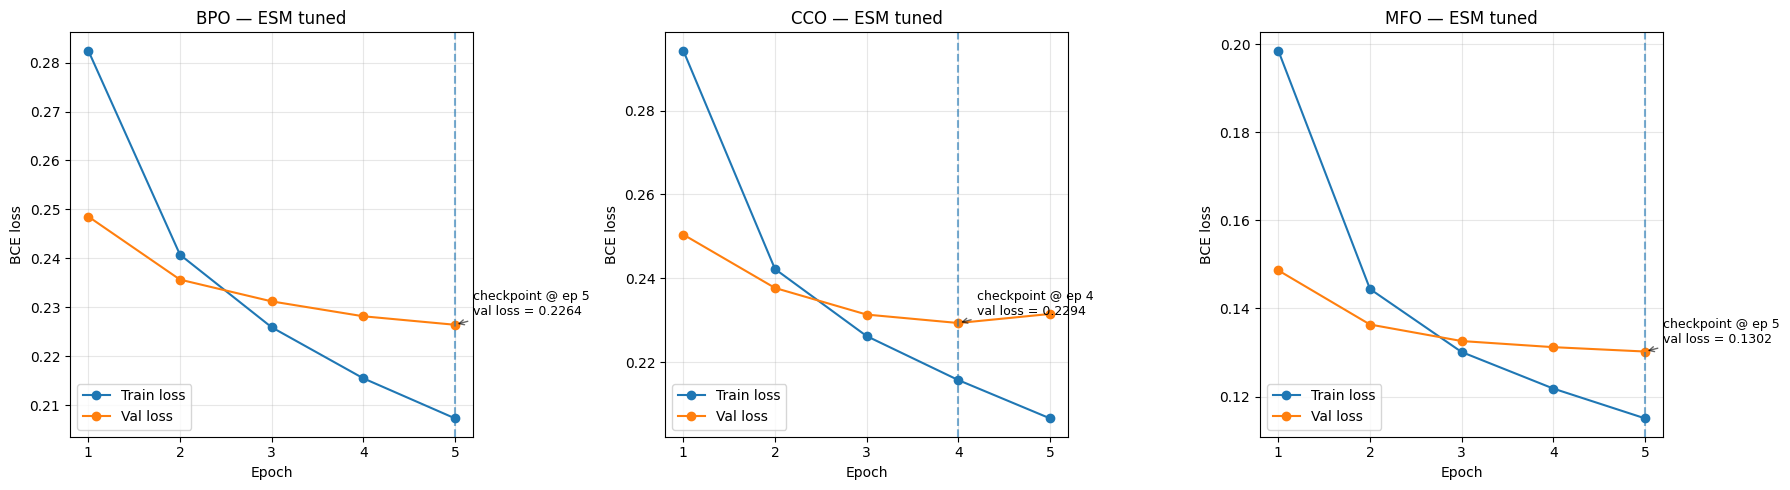

In [21]:
tuned_results = {
    "BPO": result_BPO_tuned,
    "CCO": result_CCO_tuned,
    "MFO": result_MFO_tuned,
}

plot_loss_by_namespace(tuned_results, model_name="ESM tuned")


## Step 15. Load IA Weights and Align to Filtered Namespaces

### Why this step?
For IA-weighted F1-max, each GO term needs an information accretion weight.

Because we filtered the GO label space, we align IA weights to the filtered GO term order, then slice them by BPO / CCO / MFO.

In [22]:
def load_ia_weights(path):
    ia_map = {}

    with open(path, "r") as f:
        for line in f:
            line = line.strip()

            if not line:
                continue

            go_term, weight = line.split()
            ia_map[go_term] = float(weight)

    return ia_map


ia_map = load_ia_weights(IA_PATH)

ia_weights_filtered = np.array(
    [ia_map.get(go, 0.0) for go in go_terms_filtered],
    dtype=np.float32
)

ia_weights_BPO = ia_weights_filtered[bpo_idx]
ia_weights_CCO = ia_weights_filtered[cco_idx]
ia_weights_MFO = ia_weights_filtered[mfo_idx]

print("IA weights filtered:", ia_weights_filtered.shape)
print("IA weights BPO:", ia_weights_BPO.shape)
print("IA weights CCO:", ia_weights_CCO.shape)
print("IA weights MFO:", ia_weights_MFO.shape)

IA weights filtered: (10617,)
IA weights BPO: (7983,)
IA weights CCO: (1065,)
IA weights MFO: (1569,)


## Step 16. Define IA-weighted F1-max

### Why this step?
Standard micro-F1 and macro-F1 treat GO terms uniformly.  
IA-weighted F1-max gives more weight to informative GO terms.

For each threshold:
1. Convert probabilities to binary predictions
2. Compute weighted TP / FP / FN
3. Compute weighted precision and recall
4. Compute weighted F1
5. Select the maximum weighted F1 across thresholds

In [23]:
def weighted_fmax_from_probs(y_true, y_prob, ia_weights, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.05, 0.95, 0.1)

    eps = 1e-12
    records = []

    for t in thresholds:
        y_pred = (y_prob >= t).astype(np.int8)

        tp = ((y_true == 1) & (y_pred == 1)).sum(axis=0).astype(np.float64)
        fp = ((y_true == 0) & (y_pred == 1)).sum(axis=0).astype(np.float64)
        fn = ((y_true == 1) & (y_pred == 0)).sum(axis=0).astype(np.float64)

        weighted_tp = (tp * ia_weights).sum()
        weighted_fp = (fp * ia_weights).sum()
        weighted_fn = (fn * ia_weights).sum()

        weighted_precision = weighted_tp / (weighted_tp + weighted_fp + eps)
        weighted_recall = weighted_tp / (weighted_tp + weighted_fn + eps)
        weighted_f1 = 2 * weighted_precision * weighted_recall / (weighted_precision + weighted_recall + eps)

        records.append({
            "threshold": float(t),
            "weighted_precision": float(weighted_precision),
            "weighted_recall": float(weighted_recall),
            "weighted_f1": float(weighted_f1),
        })

    best_row = max(records, key=lambda x: x["weighted_f1"])
    return records, best_row

## Step 17. Collect Validation Predictions and Compute F1-max

### Why this step?
The previous training step already computed micro-F1 and macro-F1.  
Here we collect validation probabilities again to compute IA-weighted F1-max.

In [24]:
_, val_loader_BPO = build_dataloaders(train_dataset_BPO, val_dataset_BPO, BASELINE_NAMESPACE_CONFIG["batch_size"])
_, val_loader_CCO = build_dataloaders(train_dataset_CCO, val_dataset_CCO, BASELINE_NAMESPACE_CONFIG["batch_size"])
_, val_loader_MFO = build_dataloaders(train_dataset_MFO, val_dataset_MFO, BASELINE_NAMESPACE_CONFIG["batch_size"])

baseline_probs_BPO, baseline_targets_BPO = get_predictions(result_BPO_base["model"], val_loader_BPO, device)
tuned_probs_BPO, tuned_targets_BPO = get_predictions(result_BPO_tuned["model"], val_loader_BPO, device)

baseline_probs_CCO, baseline_targets_CCO = get_predictions(result_CCO_base["model"], val_loader_CCO, device)
tuned_probs_CCO, tuned_targets_CCO = get_predictions(result_CCO_tuned["model"], val_loader_CCO, device)

baseline_probs_MFO, baseline_targets_MFO = get_predictions(result_MFO_base["model"], val_loader_MFO, device)
tuned_probs_MFO, tuned_targets_MFO = get_predictions(result_MFO_tuned["model"], val_loader_MFO, device)

thresholds = np.arange(0.05, 0.95, 0.1)

baseline_fmax_records_BPO, baseline_best_fmax_BPO = weighted_fmax_from_probs(
    baseline_targets_BPO, baseline_probs_BPO, ia_weights_BPO, thresholds=thresholds
)

tuned_fmax_records_BPO, tuned_best_fmax_BPO = weighted_fmax_from_probs(
    tuned_targets_BPO, tuned_probs_BPO, ia_weights_BPO, thresholds=thresholds
)

baseline_fmax_records_CCO, baseline_best_fmax_CCO = weighted_fmax_from_probs(
    baseline_targets_CCO, baseline_probs_CCO, ia_weights_CCO, thresholds=thresholds
)

tuned_fmax_records_CCO, tuned_best_fmax_CCO = weighted_fmax_from_probs(
    tuned_targets_CCO, tuned_probs_CCO, ia_weights_CCO, thresholds=thresholds
)

baseline_fmax_records_MFO, baseline_best_fmax_MFO = weighted_fmax_from_probs(
    baseline_targets_MFO, baseline_probs_MFO, ia_weights_MFO, thresholds=thresholds
)

tuned_fmax_records_MFO, tuned_best_fmax_MFO = weighted_fmax_from_probs(
    tuned_targets_MFO, tuned_probs_MFO, ia_weights_MFO, thresholds=thresholds
)

print("BPO baseline F1-max:", baseline_best_fmax_BPO)
print("BPO tuned F1-max:", tuned_best_fmax_BPO)
print("CCO baseline F1-max:", baseline_best_fmax_CCO)
print("CCO tuned F1-max:", tuned_best_fmax_CCO)
print("MFO baseline F1-max:", baseline_best_fmax_MFO)
print("MFO tuned F1-max:", tuned_best_fmax_MFO)

BPO baseline F1-max: {'threshold': 0.8500000000000002, 'weighted_precision': 0.11843883609473282, 'weighted_recall': 0.19259785842264568, 'weighted_f1': 0.14667765307394262}
BPO tuned F1-max: {'threshold': 0.7500000000000002, 'weighted_precision': 0.09909464582364472, 'weighted_recall': 0.3158345245788958, 'weighted_f1': 0.1508571225377402}
CCO baseline F1-max: {'threshold': 0.8500000000000002, 'weighted_precision': 0.16335011879091965, 'weighted_recall': 0.2977612956605294, 'weighted_f1': 0.21096568635258298}
CCO tuned F1-max: {'threshold': 0.8500000000000002, 'weighted_precision': 0.17439831430596225, 'weighted_recall': 0.25267565409169046, 'weighted_f1': 0.20636335342552922}
MFO baseline F1-max: {'threshold': 0.8500000000000002, 'weighted_precision': 0.17809465118875273, 'weighted_recall': 0.43178839684128273, 'weighted_f1': 0.25217688594907717}
MFO tuned F1-max: {'threshold': 0.8500000000000002, 'weighted_precision': 0.1950676950349568, 'weighted_recall': 0.42884917645683435, 'weig

## Step 18. Build Baseline vs Tuned Comparison Table

### What we compare
For each namespace:
- best micro-F1
- best macro-F1
- IA-weighted F1-max
- best validation loss

In [25]:
comparison_all_df = pd.DataFrame([
    {
        "namespace": "BPO",
        "model": "baseline",
        "micro_f1": result_BPO_base["best_micro_row"]["micro_f1"],
        "macro_f1": result_BPO_base["best_macro_row"]["macro_f1"],
        "f1_max": baseline_best_fmax_BPO["weighted_f1"],
        "best_val_loss": result_BPO_base["best_val_loss"],
        "model_path": result_BPO_base["model_path"],
    },
    {
        "namespace": "BPO",
        "model": "tuned",
        "micro_f1": result_BPO_tuned["best_micro_row"]["micro_f1"],
        "macro_f1": result_BPO_tuned["best_macro_row"]["macro_f1"],
        "f1_max": tuned_best_fmax_BPO["weighted_f1"],
        "best_val_loss": result_BPO_tuned["best_val_loss"],
        "model_path": result_BPO_tuned["model_path"],
    },
    {
        "namespace": "CCO",
        "model": "baseline",
        "micro_f1": result_CCO_base["best_micro_row"]["micro_f1"],
        "macro_f1": result_CCO_base["best_macro_row"]["macro_f1"],
        "f1_max": baseline_best_fmax_CCO["weighted_f1"],
        "best_val_loss": result_CCO_base["best_val_loss"],
        "model_path": result_CCO_base["model_path"],
    },
    {
        "namespace": "CCO",
        "model": "tuned",
        "micro_f1": result_CCO_tuned["best_micro_row"]["micro_f1"],
        "macro_f1": result_CCO_tuned["best_macro_row"]["macro_f1"],
        "f1_max": tuned_best_fmax_CCO["weighted_f1"],
        "best_val_loss": result_CCO_tuned["best_val_loss"],
        "model_path": result_CCO_tuned["model_path"],
    },
    {
        "namespace": "MFO",
        "model": "baseline",
        "micro_f1": result_MFO_base["best_micro_row"]["micro_f1"],
        "macro_f1": result_MFO_base["best_macro_row"]["macro_f1"],
        "f1_max": baseline_best_fmax_MFO["weighted_f1"],
        "best_val_loss": result_MFO_base["best_val_loss"],
        "model_path": result_MFO_base["model_path"],
    },
    {
        "namespace": "MFO",
        "model": "tuned",
        "micro_f1": result_MFO_tuned["best_micro_row"]["micro_f1"],
        "macro_f1": result_MFO_tuned["best_macro_row"]["macro_f1"],
        "f1_max": tuned_best_fmax_MFO["weighted_f1"],
        "best_val_loss": result_MFO_tuned["best_val_loss"],
        "model_path": result_MFO_tuned["model_path"],
    },
])

display(comparison_all_df)

comparison_csv_path = os.path.join(OUTPUT_DIR, "esm_freq20_baseline_tuned_metrics.csv")
comparison_all_df.to_csv(comparison_csv_path, index=False)

print("Saved comparison table to:", comparison_csv_path)

,namespace,model,micro_f1,macro_f1,f1_max,best_val_loss,model_path
0,BPO,baseline,0.161491,0.087432,0.146678,0.225212,esm_GO_split_freq20_full_outputs/esm_freq20_BP...
1,BPO,tuned,0.176281,0.091704,0.150857,0.226449,esm_GO_split_freq20_full_outputs/esm_freq20_BP...
2,CCO,baseline,0.262683,0.178575,0.210966,0.229830,esm_GO_split_freq20_full_outputs/esm_freq20_CC...
3,CCO,tuned,0.256733,0.166756,0.206363,0.229387,esm_GO_split_freq20_full_outputs/esm_freq20_CC...
4,MFO,baseline,0.261879,0.251396,0.252177,0.129869,esm_GO_split_freq20_full_outputs/esm_freq20_MF...
5,MFO,tuned,0.274603,0.257650,0.268160,0.130228,esm_GO_split_freq20_full_outputs/esm_freq20_MF...


Saved comparison table to: esm_GO_split_freq20_full_outputs/esm_freq20_baseline_tuned_metrics.csv


## Step 14. Final Test Evaluation with IA-weighted Fmax

This section keeps the training and validation workflow unchanged.

- Train set: model fitting
- Validation set: early stopping and tuning
- Test set: final evaluation only

We report IA-weighted Fmax on the held-out test set for ESM, then compare it against the K-mer test metrics saved in `data_processed_kmer_70/kmer_test_metrics.csv`.


In [26]:
# -----------------------------
# Final test evaluation: ESM IA-weighted Fmax
# -----------------------------

test_dataset_BPO = ProteinESMDataset(X_test, Y_test_BPO)
test_dataset_CCO = ProteinESMDataset(X_test, Y_test_CCO)
test_dataset_MFO = ProteinESMDataset(X_test, Y_test_MFO)

batch_size = TUNED_NAMESPACE_CONFIG["batch_size"]

test_loader_BPO = DataLoader(test_dataset_BPO, batch_size=batch_size, shuffle=False)
test_loader_CCO = DataLoader(test_dataset_CCO, batch_size=batch_size, shuffle=False)
test_loader_MFO = DataLoader(test_dataset_MFO, batch_size=batch_size, shuffle=False)

test_loaders = {
    "BPO": test_loader_BPO,
    "CCO": test_loader_CCO,
    "MFO": test_loader_MFO,
}

results_dict = {
    "BPO": result_BPO_tuned,
    "CCO": result_CCO_tuned,
    "MFO": result_MFO_tuned,
}

ia_weights_dict = {
    "BPO": ia_weights_BPO,
    "CCO": ia_weights_CCO,
    "MFO": ia_weights_MFO,
}

# Safety check: each namespace label matrix must align with its IA weights
for ns in ["BPO", "CCO", "MFO"]:
    y_dim = test_loaders[ns].dataset.Y.shape[1]
    w_dim = ia_weights_dict[ns].shape[0]
    print(ns, "Y_test dim:", y_dim, "| IA weight dim:", w_dim)
    assert y_dim == w_dim, f"{ns}: Y_test label dimension does not match IA weights."

thresholds = np.arange(0.05, 0.95, 0.1)
esm_test_rows = []

for namespace, result in results_dict.items():
    test_probs, test_targets = get_predictions(
        result["model"],
        test_loaders[namespace],
        device
    )

    test_fmax_records, test_best_fmax = weighted_fmax_from_probs(
        y_true=test_targets,
        y_prob=test_probs,
        ia_weights=ia_weights_dict[namespace],
        thresholds=thresholds
    )

    esm_test_rows.append({
        "namespace": namespace,
        "model": "ESM tuned",
        "ia_fmax": test_best_fmax["weighted_f1"],
        "ia_threshold": test_best_fmax["threshold"],
        "ia_precision": test_best_fmax["weighted_precision"],
        "ia_recall": test_best_fmax["weighted_recall"],
        "best_val_loss": result["best_val_loss"],
        "model_path": result["model_path"],
    })

esm_test_metrics_df = pd.DataFrame(esm_test_rows)

esm_test_path = os.path.join(OUTPUT_DIR, "esm_test_metrics.csv")
esm_test_metrics_df.to_csv(esm_test_path, index=False)

display(esm_test_metrics_df)
print("Saved ESM test metrics to:", esm_test_path)


BPO Y_test dim: 7983 | IA weight dim: 7983
CCO Y_test dim: 1065 | IA weight dim: 1065
MFO Y_test dim: 1569 | IA weight dim: 1569


,namespace,model,ia_fmax,ia_threshold,ia_precision,ia_recall,best_val_loss,model_path
0,BPO,ESM tuned,0.150923,0.75,0.099121,0.316139,0.226449,esm_GO_split_freq20_full_outputs/esm_freq20_BP...
1,CCO,ESM tuned,0.207403,0.85,0.174987,0.254562,0.229387,esm_GO_split_freq20_full_outputs/esm_freq20_CC...
2,MFO,ESM tuned,0.269435,0.85,0.196214,0.429836,0.130228,esm_GO_split_freq20_full_outputs/esm_freq20_MF...


Saved ESM test metrics to: esm_GO_split_freq20_full_outputs/esm_test_metrics.csv


## Step 15. Compare Test IA-weighted Fmax: K-mer vs ESM

This final plot reads the K-mer test result CSV and compares the held-out test IA-weighted Fmax against ESM across BPO, CCO, and MFO.


K-mer test metrics path: ../kmer/kmer_GO_split_freq20_outputs/kmer_test_metrics.csv
K-mer columns: ['namespace', 'model', 'best_val_loss', 'ia_threshold', 'ia_weighted_fmax', 'ia_weighted_precision', 'ia_weighted_recall', 'micro_f1', 'macro_f1', 'samples_f1', 'micro_precision', 'micro_recall']
ESM columns: ['namespace', 'model', 'ia_fmax', 'ia_threshold', 'ia_precision', 'ia_recall', 'best_val_loss', 'model_path']


,namespace,ia_fmax,feature
3,BPO,0.150923,ESM2
0,BPO,0.102213,K-mer
4,CCO,0.207403,ESM2
1,CCO,0.134412,K-mer
5,MFO,0.269435,ESM2
2,MFO,0.159960,K-mer


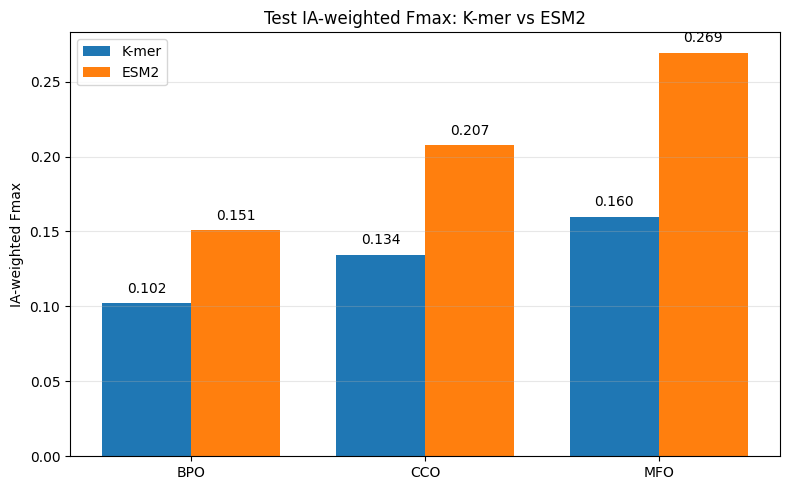

Saved figure to: esm_GO_split_freq20_full_outputs/test_ia_fmax_kmer_vs_esm.png


In [32]:
# -----------------------------
# Compare K-mer test IA-Fmax vs ESM test IA-Fmax
# -----------------------------

kmer_test_df = pd.read_csv(KMER_TEST_METRICS_PATH)

print("K-mer test metrics path:", KMER_TEST_METRICS_PATH)
print("K-mer columns:", kmer_test_df.columns.tolist())
print("ESM columns:", esm_test_metrics_df.columns.tolist())

# Normalize possible column names from the K-mer notebook
if "ia_fmax" not in kmer_test_df.columns:
    rename_candidates = {
        "ia_weighted_fmax": "ia_fmax",
        "weighted_f1": "ia_fmax",
        "f1_max": "ia_fmax",
    }

    for old_col, new_col in rename_candidates.items():
        if old_col in kmer_test_df.columns:
            kmer_test_df = kmer_test_df.rename(columns={old_col: new_col})
            break

if "ia_fmax" not in kmer_test_df.columns:
    raise ValueError(
        "Could not find IA-Fmax column in K-mer CSV. "
        "Expected one of: ia_fmax, ia_weighted_fmax, weighted_f1, f1_max."
    )

order = ["BPO", "CCO", "MFO"]

kmer_plot_df = kmer_test_df[["namespace", "ia_fmax"]].copy()
kmer_plot_df["feature"] = "K-mer"

esm_plot_df = esm_test_metrics_df[["namespace", "ia_fmax"]].copy()
esm_plot_df["feature"] = "ESM2"

plot_df = pd.concat([kmer_plot_df, esm_plot_df], ignore_index=True)
plot_df["namespace"] = pd.Categorical(plot_df["namespace"], categories=order, ordered=True)
plot_df = plot_df.sort_values(["namespace", "feature"])

display(plot_df)

pivot_df = plot_df.pivot(index="namespace", columns="feature", values="ia_fmax").loc[order]

x = np.arange(len(order))
width = 0.38

plt.figure(figsize=(8, 5))

bars1 = plt.bar(x - width/2, pivot_df["K-mer"], width, label="K-mer")
bars2 = plt.bar(x + width/2, pivot_df["ESM2"], width, label="ESM2")

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.005,
            f"{h:.3f}",
            ha="center",
            va="bottom",
            fontsize=10,
        )

plt.xticks(x, order)
plt.ylabel("IA-weighted Fmax")
plt.title("Test IA-weighted Fmax: K-mer vs ESM2")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

fig_path = os.path.join(OUTPUT_DIR, "test_ia_fmax_kmer_vs_esm.png")
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure to:", fig_path)


## Step 19. Plot Baseline vs Tuned Comparisons

### Why this step?
This figure summarizes how filtering + tuning affects:
- micro-F1
- macro-F1
- IA-weighted F1-max

across BPO / CCO / MFO.

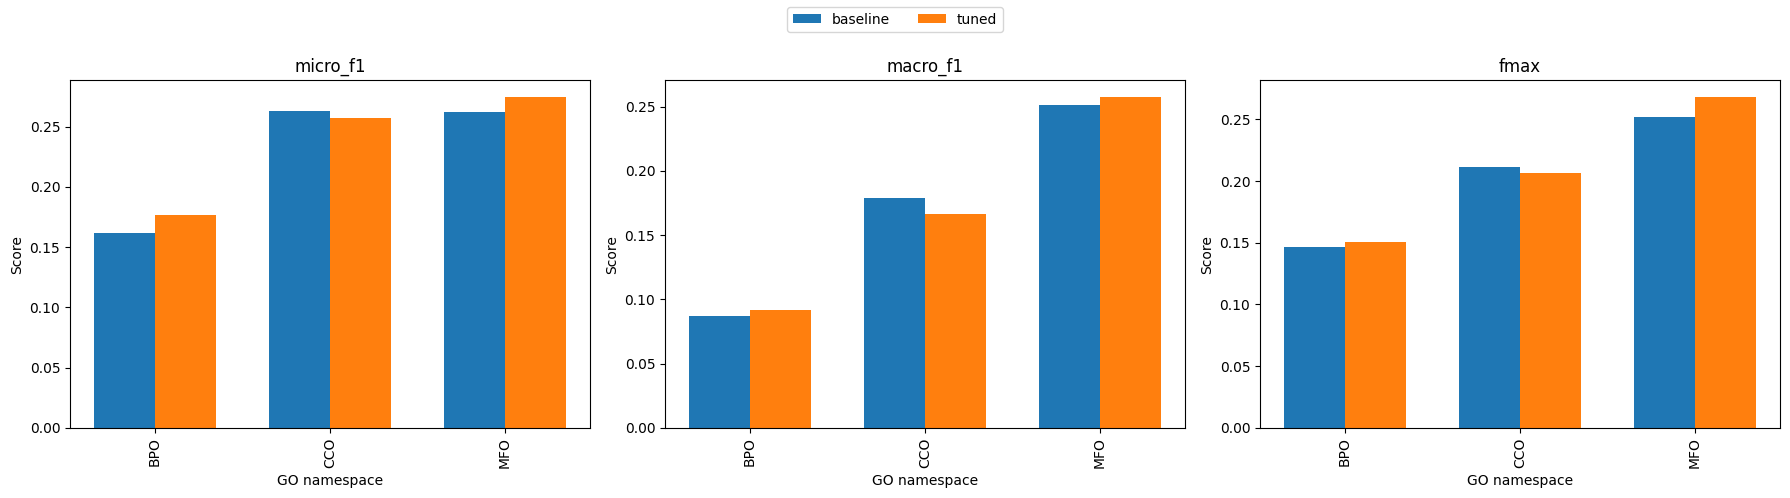

Saved figure to: esm_GO_split_freq20_full_outputs/esm_freq20_baseline_vs_tuned_metrics.png


In [33]:
def plot_namespace_metric_panels(comparison_all_df):
    namespaces = ["BPO", "CCO", "MFO"]

    metric_specs = [
        ("micro_f1", "micro_f1"),
        ("macro_f1", "macro_f1"),
        ("f1_max", "fmax"),
    ]

    x = np.arange(len(namespaces))
    width = 0.35

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, (metric_col, title) in zip(axes, metric_specs):
        baseline_scores = []
        tuned_scores = []

        for ns in namespaces:
            subset = comparison_all_df[comparison_all_df["namespace"] == ns]

            baseline_row = subset[subset["model"] == "baseline"].iloc[0]
            tuned_row = subset[subset["model"] == "tuned"].iloc[0]

            baseline_scores.append(baseline_row[metric_col])
            tuned_scores.append(tuned_row[metric_col])

        ax.bar(x - width/2, baseline_scores, width=width, label="baseline")
        ax.bar(x + width/2, tuned_scores, width=width, label="tuned")

        ax.set_xticks(x)
        ax.set_xticklabels(namespaces, rotation=90)
        ax.set_xlabel("GO namespace")
        ax.set_ylabel("Score")
        ax.set_title(title)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2)

    plt.tight_layout(rect=[0, 0, 1, 0.92])

    figure_path = os.path.join(OUTPUT_DIR, "esm_freq20_baseline_vs_tuned_metrics.png")
    plt.savefig(figure_path, dpi=200, bbox_inches="tight")

    plt.show()

    print("Saved figure to:", figure_path)


plot_namespace_metric_panels(comparison_all_df)

## Step 20. Visualize Label Space Before vs After Filtering

### Why this step?
This gives a concise view of how much the output space was reduced by removing rare GO terms.

,stage,num_go_terms
0,Original,31454
1,Filtered >= 20,10617


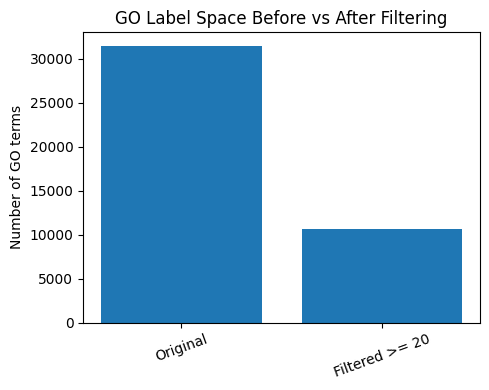

Saved figure to: esm_GO_split_freq20_full_outputs/go_label_space_before_after_filtering.png


In [34]:
filter_summary_df = pd.DataFrame([
    {"stage": "Original", "num_go_terms": int(Y_train.shape[1])},
    {"stage": f"Filtered >= {FREQ_THRESHOLD}", "num_go_terms": int(Y_train_filtered.shape[1])},
])

display(filter_summary_df)

plt.figure(figsize=(5, 4))
plt.bar(filter_summary_df["stage"], filter_summary_df["num_go_terms"])
plt.ylabel("Number of GO terms")
plt.title("GO Label Space Before vs After Filtering")
plt.xticks(rotation=20)
plt.tight_layout()

figure_path = os.path.join(OUTPUT_DIR, "go_label_space_before_after_filtering.png")
plt.savefig(figure_path, dpi=200, bbox_inches="tight")

plt.show()

print("Saved figure to:", figure_path)

## Step 21. Save Final Experiment Summary

### Why this step?
This makes the notebook more production-like by saving important configuration and results.

In [35]:
experiment_summary = {
    "feature_type": "ESM",
    "freq_threshold": FREQ_THRESHOLD,
    "original_num_go_terms": int(Y_train.shape[1]),
    "filtered_num_go_terms": int(Y_train_filtered.shape[1]),
    "num_BPO_terms": int(len(bpo_idx)),
    "num_CCO_terms": int(len(cco_idx)),
    "num_MFO_terms": int(len(mfo_idx)),
    "baseline_config": BASELINE_NAMESPACE_CONFIG,
    "tuned_config": TUNED_NAMESPACE_CONFIG,
    "metrics": comparison_all_df.to_dict(orient="records"),
    "test_metrics": esm_test_metrics_df.to_dict(orient="records") if "esm_test_metrics_df" in globals() else [],
}

summary_path = os.path.join(OUTPUT_DIR, "esm_freq20_experiment_summary.json")

with open(summary_path, "w") as f:
    json.dump(experiment_summary, f, indent=2)

print("Saved experiment summary to:", summary_path)


Saved experiment summary to: esm_GO_split_freq20_full_outputs/esm_freq20_experiment_summary.json


## Summary

This notebook preserves the original ESM GO-split tuning workflow, but filters out GO terms with fewer than 20 positive training examples before namespace splitting.

Key points:
- ESM embeddings are reused; no re-embedding is needed.
- GO filtering is applied only to labels.
- Frequency is computed from `Y_train` only.
- BPO / CCO / MFO splits are rebuilt after filtering.
- Thresholds are retuned because the label distribution changed.
- Baseline and tuned models are compared using micro-F1, macro-F1, and IA-weighted F1-max.